# Robot arm example

In [1]:
#@title Install libraries

!pip -q install vedo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 94.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 MB 17.2 MB/s eta 0:00:00


In [2]:
!pip --quiet install ipython-autotime
%load_ext autotime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.2 MB/s eta 0:00:00
time: 282 µs (started: 2026-03-10 14:20:56 +00:00)


In [3]:
#@title Import libraries
import vedo

if "google.colab" in str(get_ipython()):
    vedo.settings.init_colab()


import os
import glob
import numpy as np
import vedo

# Force VTK backend (important in Colab)
if "google.colab" in str(get_ipython()):
    if vedo.settings.default_backend != "vtk":
        print("Switching VTK backend for compatibility.")
        vedo.settings.default_backend = "vtk"



setting up colab environment (can take a minute) ...installing k3d... setup completed.
Switching VTK backend for compatibility.
time: 11.8 s (started: 2026-03-10 14:20:56 +00:00)


In [4]:
#@title  Download zip file containing robot parts from dropbox
# Only if folder robots/ does not exist
if not os.path.exists("robot/"):
  !wget -O robot.zip "https://www.dropbox.com/scl/fi/uewvrcempf2wf2jp7bcb8/robot.zip?rlkey=7uwz1ne94hxyinub8x16y93em&dl=1"
  !unzip robot.zip
  !rm robot.zip

--2026-03-10 14:21:08--  https://www.dropbox.com/scl/fi/uewvrcempf2wf2jp7bcb8/robot.zip?rlkey=7uwz1ne94hxyinub8x16y93em&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.6.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc72ed3304f2e8eda630f4281c87.dl.dropboxusercontent.com/cd/0/inline/C8YAC1fRvYnAvzus1uAJDuwQJYm3NDls7qARWx4pR2t3JJIyzfS6DNv3wiVnM5IzMKR2RbK5JIvnxWrguEYVQcmEXxUujA4ZByYmwhGHHnCjKZnhc62r5PFoDWbbnTCqvI3JLxLkj5h9vuGihsVQOE3E/file?dl=1# [following]
--2026-03-10 14:21:09--  https://uc72ed3304f2e8eda630f4281c87.dl.dropboxusercontent.com/cd/0/inline/C8YAC1fRvYnAvzus1uAJDuwQJYm3NDls7qARWx4pR2t3JJIyzfS6DNv3wiVnM5IzMKR2RbK5JIvnxWrguEYVQcmEXxUujA4ZByYmwhGHHnCjKZnhc62r5PFoDWbbnTCqvI3JLxLkj5h9vuGihsVQOE3E/file?dl=1
Resolving uc72ed3304f2e8eda630f4281c87.dl.dropboxusercontent.com (uc72ed3304f2e8eda630f4281c87.dl.dropboxusercontent.com)... 162.125.

In [5]:
#@title Imports
import os
import glob
import numpy as np
import vedo

from vedo import (
    load,
    Axes,
    Circle,
    Arrow,
    Sphere,
    Plotter,
    LinearTransform,
)

time: 432 µs (started: 2026-03-10 14:21:12 +00:00)


In [20]:
#@title Robot class

class RobotArm:
    """
    Robot arm with:
      - forward kinematics
      - Jacobian-based IK
      - persistent vedo meshes updated in-place
    """

    def __init__(self, partLengths, parts, arm_location):
        # Arm location (position of the first frame)
        self.arm_location = np.array(arm_location, dtype=float)

        # Lengths
        self.L1, self.L2, self.L3, self.L4 = partLengths

        # Store source meshes (do not mutate these directly)
        self.source_parts = parts

        # Constants
        self.delta_phi = 0.1              # finite-difference step, in degrees
        self.target = np.array([0, 100, 200], dtype=float)
        self.target_tolerance = 30
        self.target_lambda = 0.001
        self.convergence = 0.02
        self.iteration_limit = 1000

        # Live meshes for rendering
        self.meshes = None
        self.initialize_meshes()

    def initialize_meshes(self):
        """
        Create robot meshes once for this robot instance.
        These are the only meshes used during animation.
        """
        Base  = self.source_parts[0].clone()
        Part1 = self.source_parts[1].clone()
        Part2 = self.source_parts[2].clone()
        Part3 = self.source_parts[3].clone()
        Part4 = self.createCoordinateFrameMesh()

        self.meshes = [Base, Part1, Part2, Part3, Part4]

    def RotationMatrix(self, theta, axis_name):
        """
        Single-axis rotation matrix.
        theta is interpreted in degrees.
        """
        c = np.cos(theta * np.pi / 180.0)
        s = np.sin(theta * np.pi / 180.0)

        if axis_name == "x":
            rotation_matrix = np.array([
                [1, 0,  0],
                [0, c, -s],
                [0, s,  c]
            ])
        elif axis_name == "y":
            rotation_matrix = np.array([
                [ c, 0, s],
                [ 0, 1, 0],
                [-s, 0, c]
            ])
        elif axis_name == "z":
            rotation_matrix = np.array([
                [c, -s, 0],
                [s,  c, 0],
                [0,  0, 1]
            ])
        else:
            raise ValueError(f"Unknown axis_name: {axis_name}")

        return rotation_matrix

    def createCoordinateFrameMesh(self):
        """
        Returns a mesh representing a coordinate frame.
        """
        shaft_radius = 0.05
        head_radius = 0.10
        alpha = 1.0
        unit = 30

        x_axisArrow = Arrow(
            start_pt=(0, 0, 0),
            end_pt=(unit, 0, 0),
            shaft_radius=shaft_radius,
            head_radius=head_radius,
            res=12,
            c="red",
            alpha=alpha,
        )

        y_axisArrow = Arrow(
            start_pt=(0, 0, 0),
            end_pt=(0, unit, 0),
            shaft_radius=shaft_radius,
            head_radius=head_radius,
            res=12,
            c="green",
            alpha=alpha,
        )

        z_axisArrow = Arrow(
            start_pt=(0, 0, 0),
            end_pt=(0, 0, unit),
            shaft_radius=shaft_radius,
            head_radius=head_radius,
            res=12,
            c="blue",
            alpha=alpha,
        )

        originDot = Sphere(pos=[0, 0, 0], c="black", r=0.10 * unit)

        F = x_axisArrow + y_axisArrow + z_axisArrow + originDot
        return F

    def getLocalFrameMatrix(self, R_ij, t_ij):
        """
        Homogeneous transform matrix T_ij from rotation R_ij and translation t_ij.
        """
        T_ij = np.block([
            [R_ij, t_ij],
            [np.zeros((1, 3)), np.array([[1]])]
        ])
        return T_ij

    def forward_kinematics(self, Phi):
        """
        Returns:
            T_00, T_01, T_02, T_03, T_04, e
        where e is the end-effector position.
        """
        radius = 0.4

        phi1 = Phi[0]

        # Base
        R_00 = self.RotationMatrix(0, axis_name="z")
        t_00 = np.copy(self.arm_location)
        t_00[-1] = 0
        T_00 = self.getLocalFrameMatrix(R_00, t_00)

        # Frame 1
        R_01 = self.RotationMatrix(phi1, axis_name="z")
        t_01 = self.arm_location
        T_01 = self.getLocalFrameMatrix(R_01, t_01)

        # Frame 2
        phi2 = Phi[1]
        R_12 = self.RotationMatrix(phi2, axis_name="y")
        t_12 = np.array([[0.0], [0.0], [self.L1 + 2 * radius]])
        T_12 = self.getLocalFrameMatrix(R_12, t_12)
        T_02 = T_01 @ T_12

        # Frame 3
        phi3 = Phi[2]
        R_23 = self.RotationMatrix(phi3, axis_name="y")
        t_23 = np.array([[0.0], [0.0], [self.L2 + 2 * radius]])
        T_23 = self.getLocalFrameMatrix(R_23, t_23)
        T_03 = T_01 @ T_12 @ T_23

        # Frame 4 / end effector
        phi4 = Phi[3]
        R_34 = self.RotationMatrix(phi4, axis_name="y")
        t_34 = np.array([[-28.4], [0.0], [self.L3 + radius]])
        T_34 = self.getLocalFrameMatrix(R_34, t_34)
        T_04 = T_01 @ T_12 @ T_23 @ T_34

        e = T_04[0:3, -1]
        return T_00, T_01, T_02, T_03, T_04, e

    def get_pose_transforms(self, Phi):
        """
        Convenience function for rendering.
        """
        T_00, T_01, T_02, T_03, T_04, _ = self.forward_kinematics(Phi)
        return [T_00, T_01, T_02, T_03, T_04]

    def update_pose(self, Phi):
        """
        Update the robot's existing meshes in-place.
        No cloning, no mesh accumulation.
        """
        transforms = self.get_pose_transforms(Phi)

        # Re-clone from the original neutral meshes each frame to avoid
        # transform accumulation issues across frames.
        Base  = self.source_parts[0].clone()
        Part1 = self.source_parts[1].clone()
        Part2 = self.source_parts[2].clone()
        Part3 = self.source_parts[3].clone()
        Part4 = self.createCoordinateFrameMesh()

        new_meshes = [Base, Part1, Part2, Part3, Part4]

        for mesh, T in zip(new_meshes, transforms):
            mesh.apply_transform(LinearTransform(T))

        self.meshes = new_meshes
        return self.meshes



    def jacobian_matrix(self, phi):
        """
        Numerical Jacobian of end-effector position wrt joint angles.
        """
        # Keep everything in degrees to match the rest of your code
        step = self.delta_phi

        _, _, _, _, _, e = self.forward_kinematics(phi)

        _, _, _, _, _, e_phi1_delta = self.forward_kinematics(phi + np.array([step, 0, 0, 0]))
        e_phi1_derive = (e_phi1_delta - e) / step

        _, _, _, _, _, e_phi2_delta = self.forward_kinematics(phi + np.array([0, step, 0, 0]))
        e_phi2_derive = (e_phi2_delta - e) / step

        _, _, _, _, _, e_phi3_delta = self.forward_kinematics(phi + np.array([0, 0, step, 0]))
        e_phi3_derive = (e_phi3_delta - e) / step

        jacobian = np.concatenate(
            (
                e_phi1_derive.reshape((3, 1)),
                e_phi2_derive.reshape((3, 1)),
                e_phi3_derive.reshape((3, 1)),
            ),
            axis=1,
        )

        return jacobian

    def inverse_kinematics_newton(self, initial_phi, record_every=20, motion_threshold=10):
        """
        Runs IK and stores only joint angles.

        Returns
        -------
        trajectory : (N, 4) ndarray
            Recorded joint-angle states.
        """
        phi = np.array(initial_phi, dtype=float).copy()
        _, _, _, _, _, e = self.forward_kinematics(phi)

        target = np.array(self.target, dtype=float)
        target_lambda = self.target_lambda
        convergence = self.convergence
        target_tolerance = self.target_tolerance
        iteration_limit = self.iteration_limit

        recorder = [phi.copy()]
        iteration = 0
        e_accumulate = 0.0

        while np.linalg.norm(target - e) > target_tolerance:
            iteration += 1

            J = self.jacobian_matrix(phi)
            J_pinv = np.linalg.pinv(J)

            e_delta = target_lambda * (target - e)
            phi_delta = J_pinv @ e_delta
            phi_delta = np.append(phi_delta, [0.0])

            phi = phi + phi_delta

            e_previous = e
            _, _, _, _, _, e = self.forward_kinematics(phi)
            e_accumulate += np.linalg.norm(e_previous - e)

            if iteration % record_every == 0 or e_accumulate > motion_threshold:
                recorder.append(phi.copy())
                e_accumulate = 0.0

            if np.linalg.norm(e_previous - e) < convergence:
                break

            if iteration > iteration_limit:
                break

        # Always include final pose
        if not np.allclose(recorder[-1], phi):
            recorder.append(phi.copy())

        return np.array(recorder)

time: 5.61 ms (started: 2026-03-10 14:25:11 +00:00)


In [7]:
# -----------------------------
#@title Clear video frames
# -----------------------------
frames_dir = "frames"
os.makedirs(frames_dir, exist_ok=True)

for f in glob.glob(os.path.join(frames_dir, "*.png")):
    os.remove(f)

print("Old frames cleared.")

Old frames cleared.
time: 1.4 ms (started: 2026-03-10 14:21:12 +00:00)


In [21]:
#@title Scene setup and robot creation
#@markdown This cell loads the STL files, creates the three robots, and prepares the common scene.

# --------------------------------------------------
# Settings
# --------------------------------------------------
unit = 1
BaseH = 105 / unit
BaseRotH = 81 / unit
HumerusH = 217 / unit
RadiusH = 416 / unit

BaseX = 10 / unit
BaseY = 10 / unit

Circle_radius = 550 / unit

BasePos = [
    [Circle_radius, 0],
    [Circle_radius * np.cos(120 * np.pi / 180),  Circle_radius * np.sin(120 * np.pi / 180)],
    [Circle_radius * np.cos(-120 * np.pi / 180), Circle_radius * np.sin(-120 * np.pi / 180)],
]

L = [BaseRotH, HumerusH, RadiusH, 0]

view_angle = [1, 1, 1]

# --------------------------------------------------
# Load meshes
# --------------------------------------------------
robot_dir = "robot/"
Base    = load(robot_dir + "Base.stl").color("blue5")
BaseRot = load(robot_dir + "BaseRot.stl").color("lightblue")
Humerus = load(robot_dir + "Humerus.stl").color("gray5")
Radius  = load(robot_dir + "Radius.stl").color("red5")

parts = [Base, BaseRot, Humerus, Radius]

# --------------------------------------------------
# Arm locations
# --------------------------------------------------
arm_location0 = np.array([[BasePos[0][0]], [BasePos[0][1]], [BaseH]], dtype=float)
arm_location1 = np.array([[BasePos[1][0]], [BasePos[1][1]], [BaseH]], dtype=float)
arm_location2 = np.array([[BasePos[2][0]], [BasePos[2][1]], [BaseH]], dtype=float)

# --------------------------------------------------
# Create robot instances
# --------------------------------------------------
myRobot0 = RobotArm(L, parts, arm_location0)
myRobot1 = RobotArm(L, parts, arm_location1)
myRobot2 = RobotArm(L, parts, arm_location2)

# --------------------------------------------------
# Scene actors
# --------------------------------------------------
axes = Axes(
    xrange=(-Circle_radius * 1.2, Circle_radius * 1.2),
    yrange=(-Circle_radius * 1.2, Circle_radius * 1.2),
    zrange=(0, Circle_radius * 1.2),
)

circle = Circle(pos=(0, 0, 0), r=Circle_radius, res=120, c="lightgray", alpha=1.0)
ball = Sphere(myRobot0.target, r=30).c("red")

# --------------------------------------------------
# Plotter
# --------------------------------------------------
# plt = Plotter(size=(600, 600), bg="white", offscreen=True, interactive=False)

time: 1.49 s (started: 2026-03-10 14:26:05 +00:00)


In [22]:
# Set the limits of the graph x, y, and z ranges
#axes = Axes(xrange=(-Circle_radius*1.2,Circle_radius*1.2), yrange=(-Circle_radius*1.2,Circle_radius*1.2), zrange=(0,Circle_radius*1.2))
#circle = Circle(pos=(0, 0, 0), r=Circle_radius, res=120, c='lightgray', alpha=1.0)
# declare the class instance
plt_vtk = Plotter(size=(300, 300), bg="white", axes=10, offscreen=True, interactive=False)
plt_vtk.show(axes, viewup = view_angle)

# # A short sequence of poses
# Poses = np.array([[  0,  0,  0,  0],
# 					[-30, 50, 30,  0],
# 					[ 30,-50,-30,  0],
# 					[  0,  0,  0,  0]])


time: 113 ms (started: 2026-03-10 14:26:10 +00:00)


In [23]:
#@title Define initial joint states and solve IK


# Initial poses for each arm
phi0_init = np.array([0.0, 0.0, 0.0, 0.0])
phi1_init = np.array([0.0, 0.0, 0.0, 0.0])
phi2_init = np.array([0.0, 0.0, 0.0, 0.0])

# Solve IK and store only joint angles
traj0 = myRobot0.inverse_kinematics_newton(phi0_init)
traj1 = myRobot1.inverse_kinematics_newton(phi1_init)
traj2 = myRobot2.inverse_kinematics_newton(phi2_init)

print("traj0 shape:", traj0.shape)
print("traj1 shape:", traj1.shape)
print("traj2 shape:", traj2.shape)



traj0 shape: (74, 4)
traj1 shape: (72, 4)
traj2 shape: (79, 4)
time: 2.05 s (started: 2026-03-10 14:26:12 +00:00)


In [29]:
traj0

array([[  0.        ,   0.        ,   0.        ,   0.        ],
       [ -2.00451032,   9.46119094, -15.27491287,   0.        ],
       [ -2.96818644,  12.38056468, -20.29456319,   0.        ],
       [ -4.14478008,  15.92907493, -26.62708465,   0.        ],
       [ -4.63952764,  17.48573523, -29.49656991,   0.        ],
       [ -5.3818606 ,  19.95698152, -34.18561465,   0.        ],
       [ -5.70956384,  21.11670541, -36.45008807,   0.        ],
       [ -6.25475645,  23.16608348, -40.56843736,   0.        ],
       [ -6.45267899,  23.95315267, -42.19500034,   0.        ],
       [ -6.85065192,  25.61602219, -45.72759485,   0.        ],
       [ -6.99855763,  26.26370748, -47.14348995,   0.        ],
       [ -7.30170169,  27.64542798, -50.25238384,   0.        ],
       [ -7.41636904,  28.18772133, -51.50996285,   0.        ],
       [ -7.65488236,  29.35054865, -54.29114202,   0.        ],
       [ -7.74635051,  29.80866005, -55.42313967,   0.        ],
       [ -7.95159637,  30

time: 3.77 ms (started: 2026-03-10 14:30:07 +00:00)


In [25]:
#@title (Optional) Set different targets for each robot

# Example:
# myRobot0.target = np.array([0, 100, 200], dtype=float)
# myRobot1.target = np.array([50, 80, 180], dtype=float)
# myRobot2.target = np.array([-50, 120, 220], dtype=float)



time: 265 µs (started: 2026-03-10 14:26:20 +00:00)


In [26]:
#@title (Optional) Save trajectories to disk

#@markdown  It can be loaded later without re-running IK:


np.save("traj0.npy", traj0)
np.save("traj1.npy", traj1)
np.save("traj2.npy", traj2)

time: 1.76 ms (started: 2026-03-10 14:26:21 +00:00)


In [27]:
#@title (Optional) Load trajectories to disk


traj0 = np.load("traj0.npy")
traj1 = np.load("traj1.npy")
traj2 = np.load("traj2.npy")

time: 1.48 ms (started: 2026-03-10 14:26:23 +00:00)


In [28]:
#@title Render animation frames from stored joint angles

#@markdown Reconstructs robot poses from the stored $\phi$ values.

# --------------------------------------------------
# Output folder
# --------------------------------------------------
frames_dir = "frames"
os.makedirs(frames_dir, exist_ok=True)

for f in glob.glob(os.path.join(frames_dir, "*.png")):
    os.remove(f)

# --------------------------------------------------
# Animation
# --------------------------------------------------
idxlimit = max(len(traj0), len(traj1), len(traj2))


plt_vtk += axes
plt_vtk += circle
plt_vtk += ball

for actor in myRobot0.meshes:
    plt_vtk += actor
for actor in myRobot1.meshes:
    plt_vtk += actor
for actor in myRobot2.meshes:
    plt_vtk += actor


for idx in range(idxlimit):
    phi0 = traj0[min(idx, len(traj0) - 1)]
    phi1 = traj1[min(idx, len(traj1) - 1)]
    phi2 = traj2[min(idx, len(traj2) - 1)]

    meshes0 = myRobot0.update_pose(phi0)
    meshes1 = myRobot1.update_pose(phi1)
    meshes2 = myRobot2.update_pose(phi2)

    plt_vtk.clear()
    plt_vtk += axes
    plt_vtk += circle
    plt_vtk += ball

    for actor in meshes0:
        plt_vtk += actor
    for actor in meshes1:
        plt_vtk += actor
    for actor in meshes2:
        plt_vtk += actor

    plt_vtk.render()
    plt_vtk.screenshot(f"{frames_dir}/frame_{idx:03d}.png")

time: 2min 24s (started: 2026-03-10 14:26:25 +00:00)


Displaying frame grid preview (sampled across sequence)...


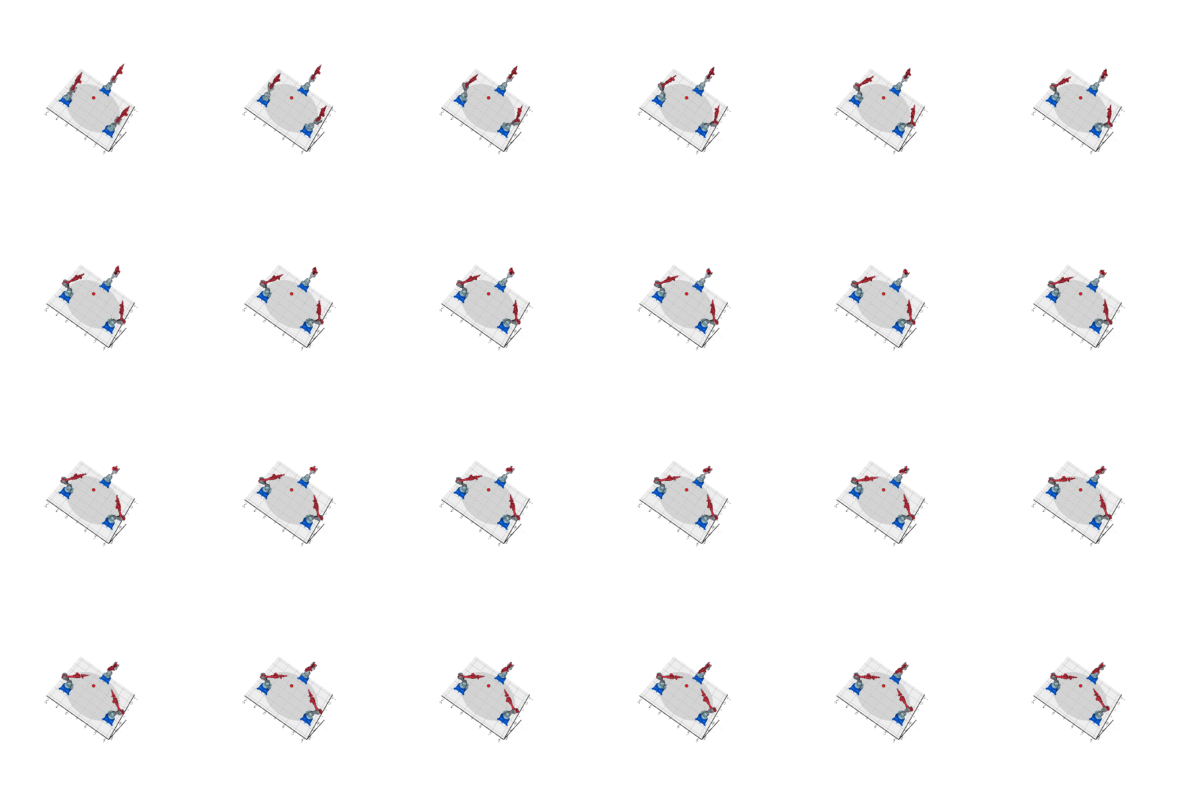

time: 452 ms (started: 2026-03-10 14:30:22 +00:00)


In [30]:
#@title Show animation sequence as a grid

import glob
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# SETTINGS
# -----------------------------
GRID_ROWS = 4
GRID_COLS = 6

# -----------------------------
# Load frames
# -----------------------------
frame_files = sorted(glob.glob(f"{frames_dir}/frame_*.png"))
N = len(frame_files)

grid_size = GRID_ROWS * GRID_COLS

if N == 0:
    raise RuntimeError("No frames found.")

# -----------------------------
# Compute sampling indices
# -----------------------------
if N <= grid_size:
    indices = np.arange(N)
else:
    step = N / grid_size
    indices = (np.arange(grid_size) * step).astype(int)

# -----------------------------
# Display grid preview
# -----------------------------
print("Displaying frame grid preview (sampled across sequence)...")

fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(12, 8))

for i in range(grid_size):
    ax = axes.flat[i]
    ax.axis("off")

    if i < len(indices):
        img = Image.open(frame_files[indices[i]])
        ax.imshow(img)

plt.tight_layout()
plt.show()

In [31]:
#@title Create video from frames
# -----------------------------
# Create video
# -----------------------------
!ffmpeg -loglevel error -y -framerate 30 -i frames/frame_%03d.png \
        -c:v libx264 -pix_fmt yuv420p -movflags +faststart spheres.mp4

print("Video created: spheres.mp4")

Video created: spheres.mp4
time: 304 ms (started: 2026-03-10 14:30:26 +00:00)


In [32]:
#@title Display video in notebook


from IPython.display import HTML
from base64 import b64encode

video_path = 'spheres.mp4'
# Read the file and encode it
mp4 = open(video_path, 'rb').read()
decoded_vid = "data:video/mp4;base64," + b64encode(mp4).decode()

# Embed in an HTML video tag
HTML(f'<video width=500 controls><source src={decoded_vid} type="video/mp4"></video>')

time: 3.18 ms (started: 2026-03-10 14:30:29 +00:00)
